In [25]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.colors as mcolors

In [26]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

model_id = "gpt2"
device = "cuda:1"
perplexity_func = "p1"

if "gpt2" in model_id:
    model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence=" "
print(f"Loaded model: {model_id}")

Loaded model: gpt2


In [27]:
model_id = "gpt2"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model : GPT2LMHeadModel = GPT2LMHeadModel.from_pretrained(model_id).to(device)
tokenizer : GPT2TokenizerFast = GPT2TokenizerFast.from_pretrained(model_id)

In [28]:
import os
os.chdir("/u/sebono/conversational_dominance/information_exchange_labelling")
os.getcwd()

'/u/sebono/conversational_dominance/information_exchange_labelling'

In [29]:
from compute_perplexity_dims import compute_p1, compute_p2, compute_p3
from utils import swap_speaker_tokens_with_metadata, get_shuffled_dialog_data, reorder_tokens

In [30]:
import numpy as np
import re
import pandas as pd

In [31]:
tri_pilot_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/triadic-pilot/conversations.csv")
tri_pilot_df

,file_name,file_content
0,p08_s03,<SPK1> Oh. Yay. It's story time. <SPK2> Hello....
1,p10_s02,<SPK3> Hello. <SPK2> Hi. <SPK0> Hi. <SPK3> You...
2,p09_s04,<SPK2> I will now turn on a start audio video ...
3,p09_s05,"<SPK0> Uh, and how did they turned on? <SPK3> ..."
4,p12_s02,<SPK2> Hello. <SPK1> Hello. <SPK0> Hello. <SPK...
...,...,...
67,p03_s05,<SPK2> [Foreign Language 00:00:57] <SPK1> [For...
68,p11_s05,<SPK0> (laughs) So funny. <SPK2> Hello. <SPK1>...
69,p12_s00,"<SPK2> Hello. <SPK1> Hi. Hi, Jibo. <SPK0> Hi, ..."
70,p10_s00,<SPK2> Hello. I am now on story time mode. My ...


In [32]:
dialog = tri_pilot_df.iloc[0]['file_content']
file_name = tri_pilot_df.iloc[0]['file_name']

In [33]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
start_of_sentence=" "
matches = re.findall(pattern, "".join(dialog_lines))
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")

Token indices sequence length is longer than the specified maximum sequence length for this model (7322 > 1024). Running this sequence through the model will result in indexing errors


In [34]:
assert len(matches) == len(dialog_lines)

In [ ]:
p1_triadic = compute_p1(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
p2_triadic = compute_p2(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
p3_triadic = compute_p3(encodings, token_list, tokenizer, model, device, start_of_sentence=" ", pattern=pattern, debug=False)

In [ ]:
all_data_pca = pd.DataFrame({"p1": p1_triadic, "p2": p2_triadic, "p3":p3_triadic})

In [35]:
file_name_sample = f'/u/sebono/conversational_dominance/information_exchange_labelling/{file_name}_triadic_ppl.csv'
all_data = pd.read_csv(file_name_sample)
all_data.head()

,p1,p2,p3,P2_pca,P3_pca
0,NaN,NaN,5.679613,8.689340,5.679613
1,8.689340,8.689340,4.582078,8.689340,4.582078
2,6.234131,7.461735,3.234659,7.461735,3.234659
3,4.770369,6.564613,2.018494,6.564613,2.018494
4,3.035107,5.682234,1.711300,5.682234,1.711300


In [36]:
from utils import correlation_heatmap

In [37]:
# AFTER
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [38]:
from sklearn.decomposition import PCA

X = np.column_stack([all_data['p2'].bfill(), all_data['p3'].bfill()])
pca = PCA(n_components=2)
X_orthogonal = pca.fit_transform(X)

In [39]:
P2_pca = X_orthogonal[:,0]
P3_pca = X_orthogonal[:,1]

In [40]:
# AFTER
all_data_pca = pd.DataFrame({"P2_pca": P2_pca, "P3_pca":P3_pca})
col_1 = ["P2_pca","P3_pca"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_pca)

In [41]:
fig_corr

In [42]:
fig_r

In [43]:
#file_name_sample = f'/u/sebono/conversational_dominance/information_exchange_labelling/{file_name}_triadic_ppl.csv'
#data_full = pd.DataFrame({'p1':all_data['p1'], 'p2':all_data['p2'], 'p3':all_data['p3'], 'P2_pca':all_data['P2_pca'], 'P3_pca':all_data['P3_pca']}).to_csv(file_name_sample, index=False)

In [44]:
all_data_pca = pd.DataFrame({'P2_pca':all_data['P2_pca'], 'P3_pca':all_data['P3_pca']})

In [45]:
from utils import rolling_kde_heatmap_with_turns, display_tokens_colored_by_kde

In [46]:
num_turns = 100
upper_limit = np.cumsum([len(token) for token in token_list])[num_turns]

In [47]:
all_data['P2_pca'][upper_limit-100:upper_limit]

1506    0.012881
1507    0.867873
1508    0.756267
1509    0.869603
1510    0.829465
          ...   
1601    2.137255
1602    2.064051
1603    2.253320
1604    2.194441
1605    2.144305
Name: P2_pca, Length: 100, dtype: float64

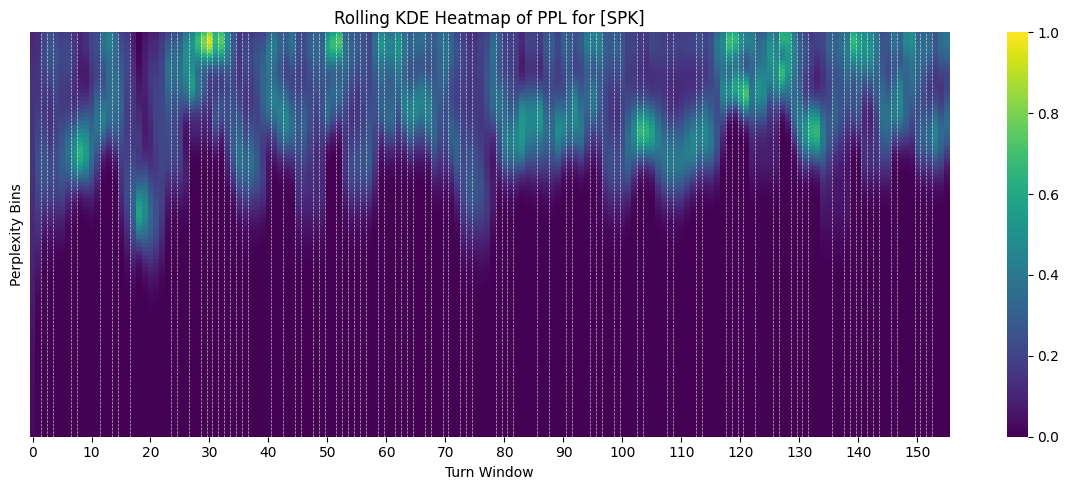

In [48]:
densities = rolling_kde_heatmap_with_turns(token_list=token_list[:num_turns], ppls=all_data["P2_pca"][:upper_limit],vmin=0, vmax=1.0)

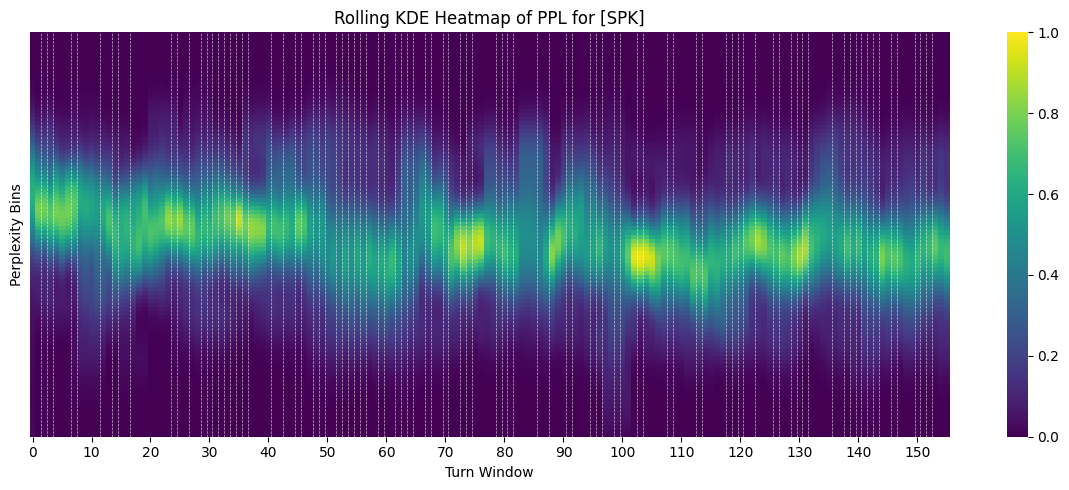

In [49]:
densities = rolling_kde_heatmap_with_turns(token_list=token_list[:num_turns], ppls=all_data["P3_pca"][:upper_limit],vmin=0, vmax=1.0)

In [50]:
html = display_tokens_colored_by_kde(
    token_list=token_list[:num_turns],
    ppls=all_data["p2"][:upper_limit],
    densities=densities,  # output from rolling KDE
    window_size=50,
    step=10,
    tokenizer=tokenizer,
    vmin=0,
    vmax=1.0
)
display(html)

### Annotations

In [51]:
annotation_file = f"/u/sebono/conversational_dominance/data/processed/triadic-pilot/annotation_files/childs-joint-engagement-with-parent/aggregated_annotation_files.csv"

In [52]:
annotations = pd.read_csv(annotation_file)
annotations_dataset = annotations[annotations['uniq_vid_clip'].str.startswith(file_name)]
annotations_dataset.head()

,Unnamed: 0,Label-Name,NAN,Start-Timestamp,Start-Timestamp(sec),End-Timestamp,End-Timestamp(sec),Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
9256,0,p08-child (joint-engagement-wt-parent),NaN,00:00:00.000,0.0,00:00:05.000,5.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-0.0,NaN,NaN
9257,1,p08-child (joint-engagement-wt-parent),NaN,00:00:05.000,5.0,00:00:10.000,10.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-5.0,NaN,NaN
9258,2,p08-child (joint-engagement-wt-parent),NaN,00:00:10.000,10.0,00:00:15.000,15.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-10.0,NaN,NaN
9259,3,p08-child (joint-engagement-wt-parent),NaN,00:00:15.000,15.0,00:00:20.000,20.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-15.0,NaN,NaN
9260,4,p08-child (joint-engagement-wt-parent),NaN,00:00:20.000,20.0,00:00:25.000,25.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-20.0,NaN,NaN


In [53]:
conversation_dataset_file = f'/u/sebono/conversational_dominance/data/external/triadic-pilot/{file_name}_REV.csv'
conversation_dataset = pd.read_csv(conversation_dataset_file)
conversation_dataset

,Unnamed: 0,timestamp,real_time,speaker,content
0,0,00:00:00,2021-06-23 09:31:47,Parent,Oh. Yay. It's story time.
1,1,00:00:07,2021-06-23 09:31:54,Robot,Hello.
2,2,00:00:07,2021-06-23 09:31:54,Parent,Hi. Hi Jibo.
3,3,00:00:10,2021-06-23 09:31:57,Robot,I am not on Story Time mode. My camera will no...
4,4,00:00:16,2021-06-23 09:32:03,Parent,Okay.
...,...,...,...,...,...
458,458,00:28:35,2021-06-23 10:00:22,Robot,And please complete the story survey with your...
459,459,00:28:38,2021-06-23 10:00:25,Parent,"All right, you ready to make your survey?"
460,460,00:28:39,2021-06-23 10:00:26,Robot,Thank you. Bye bye.
461,461,00:28:40,2021-06-23 10:00:27,Child,Bye bye.


In [54]:
assert len(matches) == len(conversation_dataset['content'])

In [55]:
conversation_dataset["tokens"] = [token.detach().numpy() for token in token_list]
conversation_dataset

,Unnamed: 0,timestamp,real_time,speaker,content,tokens
0,0,00:00:00,2021-06-23 09:31:47,Parent,Oh. Yay. It's story time.,"[27, 4303, 42, 16, 29, 3966, 13, 575, 323, 13,..."
1,1,00:00:07,2021-06-23 09:31:54,Robot,Hello.,"[27, 4303, 42, 17, 29, 18435, 13, 220]"
2,2,00:00:07,2021-06-23 09:31:54,Parent,Hi. Hi Jibo.,"[27, 4303, 42, 16, 29, 15902, 13, 15902, 449, ..."
3,3,00:00:10,2021-06-23 09:31:57,Robot,I am not on Story Time mode. My camera will no...,"[27, 4303, 42, 17, 29, 314, 716, 407, 319, 836..."
4,4,00:00:16,2021-06-23 09:32:03,Parent,Okay.,"[27, 4303, 42, 16, 29, 16805, 13, 220]"
...,...,...,...,...,...,...
458,458,00:28:35,2021-06-23 10:00:22,Robot,And please complete the story survey with your...,"[27, 4303, 42, 17, 29, 843, 3387, 1844, 262, 1..."
459,459,00:28:38,2021-06-23 10:00:25,Parent,"All right, you ready to make your survey?","[27, 4303, 42, 16, 29, 1439, 826, 11, 345, 349..."
460,460,00:28:39,2021-06-23 10:00:26,Robot,Thank you. Bye bye.,"[27, 4303, 42, 17, 29, 6952, 345, 13, 47843, 3..."
461,461,00:28:40,2021-06-23 10:00:27,Child,Bye bye.,"[27, 4303, 42, 15, 29, 47843, 33847, 13, 220]"


In [56]:
import pandas as pd

df = conversation_dataset.copy()
df["start_time"] = pd.to_timedelta(df["timestamp"]).dt.total_seconds()
df["end_time"] = df["start_time"].shift(-1)
df.loc[df.index[-1], "end_time"] = df["start_time"].iloc[-1] + 1
df = df[["start_time", "end_time", "speaker", "content", "tokens"]]
df

,start_time,end_time,speaker,content,tokens
0,0.0,7.0,Parent,Oh. Yay. It's story time.,"[27, 4303, 42, 16, 29, 3966, 13, 575, 323, 13,..."
1,7.0,7.0,Robot,Hello.,"[27, 4303, 42, 17, 29, 18435, 13, 220]"
2,7.0,10.0,Parent,Hi. Hi Jibo.,"[27, 4303, 42, 16, 29, 15902, 13, 15902, 449, ..."
3,10.0,16.0,Robot,I am not on Story Time mode. My camera will no...,"[27, 4303, 42, 17, 29, 314, 716, 407, 319, 836..."
4,16.0,16.0,Parent,Okay.,"[27, 4303, 42, 16, 29, 16805, 13, 220]"
...,...,...,...,...,...
458,1715.0,1718.0,Robot,And please complete the story survey with your...,"[27, 4303, 42, 17, 29, 843, 3387, 1844, 262, 1..."
459,1718.0,1719.0,Parent,"All right, you ready to make your survey?","[27, 4303, 42, 16, 29, 1439, 826, 11, 345, 349..."
460,1719.0,1720.0,Robot,Thank you. Bye bye.,"[27, 4303, 42, 17, 29, 6952, 345, 13, 47843, 3..."
461,1720.0,1720.0,Child,Bye bye.,"[27, 4303, 42, 15, 29, 47843, 33847, 13, 220]"


In [57]:
import numpy as np
import pandas as pd
import torch
from collections import defaultdict

def assign_words_to_bins(df, bin_size=5.0):
    """
    Assigns tokens to time bins based on uniform spread over the utterance duration.
    Includes utterances with 0 duration. Ensures all bins from time 0 to max stop are represented.

    Args:
        df (pd.DataFrame): DataFrame with columns ['start_time', 'end_time', 'tokens']
        bin_size (float): Size of each time bin in seconds

    Returns:
        pd.DataFrame: each row is a bin with its start/end time, decoded words, token indices, and token count
    """
    bin_tok = defaultdict(list)
    bin_ppl = defaultdict(list)
    global_token_idx = 0

    for _, row in df.iterrows():
        start = row["start_time"]
        stop = row["end_time"]
        tokens = row["tokens"]

        if pd.isna(start) or pd.isna(stop) or tokens is None or len(tokens) == 0:
            continue

        duration = stop - start
        if duration < 0:
            continue

        # Handle 0-duration: treat as a very short utterance
        if duration == 0:
            duration = 1e-6

        # Token timing interpolation
        tok_times = np.linspace(start, stop, len(tokens) + 1)

        for i, token in enumerate(tokens):
            tok_start = tok_times[i]
            tok_end = tok_times[i + 1]

            bin_start_idx = int(np.floor(tok_start / bin_size))
            bin_end_idx = int(np.floor((tok_end - 1e-6) / bin_size))  # avoid border collision

            for b in range(bin_start_idx, bin_end_idx + 1):
                bin_tok[b].append(token)
                bin_ppl[b].append(global_token_idx + i)

        global_token_idx += len(tokens)

    # Build output DataFrame
    max_bin = int(np.ceil(df["end_time"].max() / bin_size))
    all_bins = list(range(max_bin + 1))

    bins_df = pd.DataFrame([
        {
            "time_bin": b,
            "start_time": b * bin_size,
            "end_time": (b + 1) * bin_size,
            "words": tokenizer.decode(torch.tensor(bin_tok[b]), skip_special_tokens=True),
            "ppl": bin_ppl[b],
            "n_tok": len(bin_tok[b])
        }
        for b in all_bins
    ])

    return bins_df

In [58]:
bins_df = assign_words_to_bins(df, bin_size=5.0)

In [59]:
bins_df

,time_bin,start_time,end_time,words,ppl,n_tok
0,0,0.0,5.0,<SPK1> Oh. Yay. It's,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
1,1,5.0,10.0,'s story time. <SPK2> Hello. <SPK1> Hi. Hi Jibo.,"[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2...",25
2,2,10.0,15.0,<SPK2> I am not on Story Time mode. My camera ...,"[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 4...",23
3,3,15.0,20.0,and video recording. <SPK1> Okay. <SPK2> Let'...,"[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",25
4,4,20.0,25.0,we will be reading storybooks together. If yo...,"[82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 9...",16
...,...,...,...,...,...,...
341,341,1705.0,1710.0,<SPK2> I will now stop recording to respect yo...,"[7201, 7202, 7203, 7204, 7205, 7206, 7207, 720...",25
342,342,1710.0,1715.0,<SPK0> Bye bye. <SPK2> I will switch back to ...,"[7226, 7227, 7228, 7229, 7230, 7231, 7232, 723...",34
343,343,1715.0,1720.0,<SPK2> And please complete the story survey wi...,"[7260, 7261, 7262, 7263, 7264, 7265, 7266, 726...",45
344,344,1720.0,1725.0,<SPK1> Bye bye...,"[7314, 7315, 7316, 7317, 7318, 7319, 7320, 7321]",8


In [60]:
assert len(bins_df) == len(annotations_dataset)

In [61]:
combined_df = pd.concat([bins_df.reset_index(drop=True), annotations_dataset.iloc[:bins_df.shape[0]].reset_index(drop=True)], axis=1)
combined_df

,time_bin,start_time,end_time,words,ppl,n_tok,Unnamed: 0,Label-Name,NAN,Start-Timestamp,...,Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
0,0,0.0,5.0,<SPK1> Oh. Yay. It's,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,0,p08-child (joint-engagement-wt-parent),NaN,00:00:00.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-0.0,NaN,NaN
1,1,5.0,10.0,'s story time. <SPK2> Hello. <SPK1> Hi. Hi Jibo.,"[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2...",25,1,p08-child (joint-engagement-wt-parent),NaN,00:00:05.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-5.0,NaN,NaN
2,2,10.0,15.0,<SPK2> I am not on Story Time mode. My camera ...,"[36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 4...",23,2,p08-child (joint-engagement-wt-parent),NaN,00:00:10.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-10.0,NaN,NaN
3,3,15.0,20.0,and video recording. <SPK1> Okay. <SPK2> Let'...,"[58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 6...",25,3,p08-child (joint-engagement-wt-parent),NaN,00:00:15.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-15.0,NaN,NaN
4,4,20.0,25.0,we will be reading storybooks together. If yo...,"[82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 9...",16,4,p08-child (joint-engagement-wt-parent),NaN,00:00:20.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-20.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,341,1705.0,1710.0,<SPK2> I will now stop recording to respect yo...,"[7201, 7202, 7203, 7204, 7205, 7206, 7207, 720...",25,341,p08-child (joint-engagement-wt-parent),NaN,00:28:25.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1705.0,NaN,NaN
342,342,1710.0,1715.0,<SPK0> Bye bye. <SPK2> I will switch back to ...,"[7226, 7227, 7228, 7229, 7230, 7231, 7232, 723...",34,342,p08-child (joint-engagement-wt-parent),NaN,00:28:30.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1710.0,NaN,NaN
343,343,1715.0,1720.0,<SPK2> And please complete the story survey wi...,"[7260, 7261, 7262, 7263, 7264, 7265, 7266, 726...",45,343,p08-child (joint-engagement-wt-parent),NaN,00:28:35.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1715.0,NaN,NaN
344,344,1720.0,1725.0,<SPK1> Bye bye...,"[7314, 7315, 7316, 7317, 7318, 7319, 7320, 7321]",8,344,p08-child (joint-engagement-wt-parent),NaN,00:28:40.000,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1720.0,NaN,NaN


In [96]:
import pandas as pd

def expand_multiple_ppl_by_token(bin_df, ppl_dict, annotation_cols=None):
    """
    Expands a bin-level DataFrame into token-level rows, adding multiple PPL values per token.

    Args:
        bin_df (pd.DataFrame): must contain 'ppl' as a list of token indices.
        ppl_dict (dict): dictionary of {name: List[float]}, e.g. {'ppl1': [...], 'ppl2': [...]}
        annotation_cols (List[str]): optional list of annotation columns to repeat per token.

    Returns:
        pd.DataFrame: one row per token with multiple ppl values and repeated annotations.
    """
    # Validate that all ppl lists have the same length
    lengths = [len(v) for v in ppl_dict.values()]
    if not all(l == lengths[0] for l in lengths):
        raise ValueError("All PPL arrays must have the same length.")

    records = []

    for _, row in bin_df.iterrows():
        token_ids = row["ppl"]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        for tok_id in token_ids:
            if tok_id >= lengths[0]:
                continue  # skip out-of-bounds

            record = {"token_id": tok_id}
            for name, ppl_values in ppl_dict.items():
                record[name] = ppl_values[tok_id]

            if annotation_cols:
                for col in annotation_cols:
                    record[col] = row.get(col, None)

            records.append(record)

    return pd.DataFrame(records)

In [97]:
cols = ['Rating_x', 'Rating_y','start_time','end_time']
ppl_dict = {'P2_pca': all_data_pca["P2_pca"], 'P3_pca': all_data_pca["P3_pca"]}
all_data = expand_multiple_ppl_by_token(combined_df, ppl_dict, annotation_cols=cols)
all_data

,token_id,P2_pca,P3_pca,Rating_x,Rating_y,start_time,end_time
0,0,8.689340,5.679613,NaN,NaN,0.0,5.0
1,1,8.689340,4.582078,NaN,NaN,0.0,5.0
2,2,7.461735,3.234659,NaN,NaN,0.0,5.0
3,3,6.564613,2.018494,NaN,NaN,0.0,5.0
4,4,5.682234,1.711300,NaN,NaN,0.0,5.0
...,...,...,...,...,...,...,...
7281,7317,0.357324,3.383422,NaN,NaN,1720.0,1725.0
7282,7318,0.281780,3.144196,NaN,NaN,1720.0,1725.0
7283,7319,0.595020,3.692395,NaN,NaN,1720.0,1725.0
7284,7320,0.522660,3.201223,NaN,NaN,1720.0,1725.0


In [98]:
from sklearn.decomposition import PCA
all_data.ffill(inplace=True)
X = np.column_stack((all_data["P2_pca"][10:],all_data["P3_pca"][10:]))

In [99]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

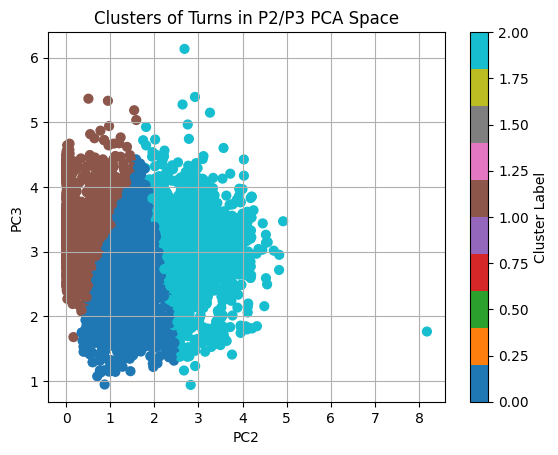

In [100]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [102]:
# AFTER
col_1 = ["P2_pca","P3_pca"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data)

In [103]:
fig_corr

In [83]:
def average_ppl_per_turn(df, ppl_dict, idx_col='ppl', annotation_cols=None):
    """
    For each row in df, average values from ppl_dict at indices listed in df[idx_col].

    Args:
        df (pd.DataFrame): DataFrame with a column of token indices (e.g., 'ppl').
        ppl_dict (dict): Dictionary with name -> list of PPL values.
        idx_col (str): Column in df with list of indices per turn.
        annotation_cols (List[str]): Optional columns to carry forward.

    Returns:
        pd.DataFrame: Averaged PPL values per turn, optionally with annotations.
    """
    import numpy as np
    import pandas as pd

    records = []
    for _, row in df.iterrows():
        token_ids = row[idx_col]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        record = {}
        for name, ppl_values in ppl_dict.items():
            selected = [ppl_values[i] for i in token_ids if i < len(ppl_values)]
            record[f'{name}_avg'] = np.mean(selected) if selected else None

        if annotation_cols:
            for col in annotation_cols:
                record[col] = row.get(col, None)

        records.append(record)

    return pd.DataFrame(records)

In [84]:
cols = ['Rating_x', 'Rating_y','words','start_time','end_time']
ppl_dict = {'P2_pca': all_data_pca["P2_pca"], 'P3_pca': all_data_pca["P3_pca"]}
all_data = average_ppl_per_turn(combined_df, ppl_dict, annotation_cols=cols)
all_data

,P2_pca_avg,P3_pca_avg,Rating_x,Rating_y,words,start_time,end_time
0,6.007881,2.708016,NaN,NaN,<SPK1> Oh. Yay. It's,0.0,5.0
1,2.636962,2.286793,NaN,NaN,'s story time. <SPK2> Hello. <SPK1> Hi. Hi Jibo.,5.0,10.0
2,2.030466,2.596161,NaN,NaN,<SPK2> I am not on Story Time mode. My camera ...,10.0,15.0
3,1.084847,2.540709,NaN,NaN,and video recording. <SPK1> Okay. <SPK2> Let'...,15.0,20.0
4,2.294928,2.532759,NaN,NaN,we will be reading storybooks together. If yo...,20.0,25.0
...,...,...,...,...,...,...,...
340,1.687078,2.849782,NaN,NaN,for today's session. I had so much fun. <SPK1...,1700.0,1705.0
341,2.132945,3.115163,NaN,NaN,<SPK2> I will now stop recording to respect yo...,1705.0,1710.0
342,0.995412,2.959459,NaN,NaN,<SPK0> Bye bye. <SPK2> I will switch back to ...,1710.0,1715.0
343,1.341709,2.991377,NaN,NaN,<SPK2> And please complete the story survey wi...,1715.0,1720.0


In [85]:
from utils import correlation_heatmap

In [86]:
# AFTER
col_1 = ["P2_pca_avg","P3_pca_avg"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data)

In [87]:
fig_corr

### Clusters

In [89]:
all_data["P2_pca_avg"]

0      6.007881
1      2.636962
2      2.030466
3      1.084847
4      2.294928
         ...   
340    1.687078
341    2.132945
342    0.995412
343    1.341709
344    0.384317
Name: P2_pca_avg, Length: 345, dtype: float64

In [90]:
from sklearn.decomposition import PCA
all_data.ffill(inplace=True)
X = np.column_stack((all_data["P2_pca_avg"][10:],all_data["P3_pca_avg"][10:]))

In [91]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

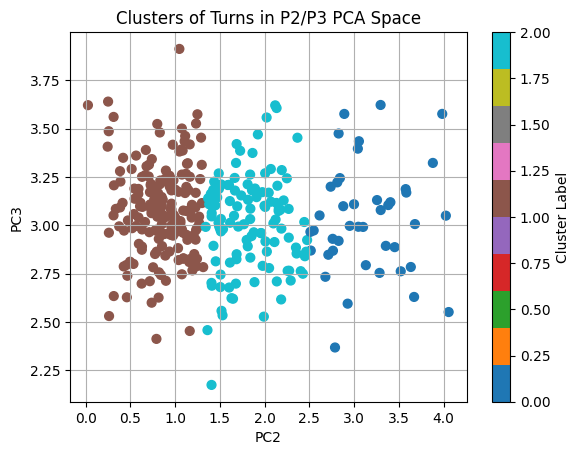

In [92]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [93]:
for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0]
    print(all_data.iloc[indices]['words'].to_numpy())



--- Cluster 0 ---
["'s story time. <SPK2> Hello. <SPK1> Hi. Hi Jibo. "
 '<SPK2> I am not on Story Time mode. My camera will now turn on and start audio and'
 " and video recording. <SPK1> Okay. <SPK2> Let's get started. Now we"
 " we will be reading storybooks together. If you haven't already, please open"
 " Oh you wanna see who it's by? By"
 ' By Bill Martin, Junior and John Archib' 'SPK0>... '
 '<SPK1> Will... Will there be enough room. Can you say'
 '<SPK1> Okay you do it. <SPK0> L, M, O'
 "K1> What's happening to the tree? "
 "<SPK1> What does that mean?  It's bending? Is the tree bending? "
 '<SPK0> Yeah. <SPK1> Fireworks make a boom sound. <SPK0> Yeah. '
 '<SPK1> TJ can you think of something that makes a boom sound? No? Nothing? Should we ask'
 ' ask Jibo? <SPK0> Yeah. <SPK1' ' Skit, skat, skoodle do, flip, flop,'
 " do you think they're called little dears? <SPK0> I don't know."
 'ars because they like them very much? Sometimes I call you dear right? Oh dear come'
 ' boom rig

### Finding Signal

In [ ]:
from utils import compute_dominance_per_spk, compute_significance

In [ ]:
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data_pca["P2_pca"], token_list, matches, tokenizer)
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data_pca["P3_pca"], token_list, matches, tokenizer)

In [ ]:
compute_significance(baselined_ppls_p2_spk), compute_significance(baselined_ppls_p3_spk) 

In [ ]:
all_data.dropna(inplace=True)

In [ ]:
from scipy.stats import spearmanr
import pandas as pd

# Perform correlation
stat, pval = spearmanr(all_data['P2_pca_avg'], all_data[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]